In [ ]:
import torch
from data_handling import BorderDataset, prepare_dataset
from model import BorderDetector
from utils import EarlyStopping, TrainingMetrics, evaluate_model, save_checkpoint
from training import train_model
import matplotlib.pyplot as plt
import numpy as np
import cv2


In [2]:
max_epochs = 75
patience = 10

# Define configurations to try
configs = [
    {
        'name': 'baseline_small',
        'conv_channels': [4, 8, 8],
        'dropout_rate': 0.1,
        'batch_size': 1,  # Reduced batch size
        'accumulation_steps': 32,  # Effective batch size
        'learning_rate': 0.001,
        'weight_decay': 0.0001,
        'num_epochs': max_epochs,
        'num_rotations': 9,
        'augment_brightness_contrast': True,
        'patience': patience,
    },
    {
        'name': 'medium_more_augment',
        'conv_channels': [8, 16, 16],
        'dropout_rate': 0.3,
        'batch_size': 1,  # Reduced batch size
        'accumulation_steps': 32,  # Effective batch size
        'learning_rate': 0.0005,
        'weight_decay': 0.001,
        'num_epochs': max_epochs,
        'num_rotations': 12,
        'augment_brightness_contrast': True,
        'patience': patience,
    },
    {
        'name': 'large_aggressive_decay',
        'conv_channels': [16, 32, 32],  # Larger model
        'dropout_rate': 0.2,
        'batch_size': 1,  # Reduce from 2 to 1
        'accumulation_steps': 32,  
        'learning_rate': 1e-4,  # Lower learning rate
        'weight_decay': 0.001,  # More aggressive decay
        'num_epochs': 3,
        'num_rotations': 9,
        'augment_brightness_contrast': True,
        'patience': patience,
    },
    {
        'name': 'small_long_training',
        'conv_channels': [4, 8, 8],
        'dropout_rate': 0.15,
        'batch_size': 1,  # Reduced batch size
        'accumulation_steps': 32,  # Effective batch size 
        'learning_rate': 0.0005,
        'weight_decay': 0.0001,
        'num_epochs': max_epochs,
        'num_rotations': 9,
        'augment_brightness_contrast': True,
        'patience': patience,
    },
    {
        'name': 'medium_heavy_augment',
        'conv_channels': [8, 16, 16],
        'dropout_rate': 0.2,
        'batch_size': 1,  # Reduced batch size
        'accumulation_steps': 32,  # Effective batch size 
        'learning_rate': 0.0005,
        'weight_decay': 0.001,
        'num_epochs': max_epochs,
        'num_rotations': 12,
        'augment_brightness_contrast': True,
        'patience': patience,
    },
    {
        'name': 'large_conservative',
        'conv_channels': [16, 32, 32],
        'dropout_rate': 0.2,
        'batch_size': 1,  # Reduced batch size
        'accumulation_steps': 32,  # Effective batch size 
        'learning_rate': 1e-4,
        'weight_decay': 0.001,
        'num_epochs': max_epochs,
        'num_rotations': 12,
        'augment_brightness_contrast': True,
        'patience': patience,
    }
]

# select only large configs
large_configs = [config for config in configs if config['name'].startswith('large')]
print(large_configs)

non_large_configs = [config for config in configs if not config['name'].startswith('large')]


[{'name': 'large_aggressive_decay', 'conv_channels': [16, 32, 32], 'dropout_rate': 0.2, 'batch_size': 1, 'accumulation_steps': 32, 'learning_rate': 0.0001, 'weight_decay': 0.001, 'num_epochs': 3, 'num_rotations': 9, 'augment_brightness_contrast': True, 'patience': 10}, {'name': 'large_conservative', 'conv_channels': [16, 32, 32], 'dropout_rate': 0.2, 'batch_size': 1, 'accumulation_steps': 32, 'learning_rate': 0.0001, 'weight_decay': 0.001, 'num_epochs': 75, 'num_rotations': 12, 'augment_brightness_contrast': True, 'patience': 10}]


In [3]:
import os
import traceback

def run_experiment(config, experiment_name, main_output_dir):
    try:
        print(f"\nStarting experiment: {experiment_name}")
        
        # Use the existing train_model function
        model, metrics_tracker, model_output_dir = train_model(config)
        
        return {
            'status': 'success',
            'experiment_name': experiment_name,
            'output_dir': model_output_dir,
            'final_val_loss': metrics_tracker.val_losses[-1],
            'final_val_accuracy': metrics_tracker.val_accuracies[-1],
            'training_history': metrics_tracker.to_dict()  # Add training history
        }
        
    except Exception as e:
        print(f"Error in experiment {experiment_name}: {str(e)}")
        print("\nFull traceback:")
        print(traceback.format_exc())
        return {
            'status': 'failed',
            'experiment_name': experiment_name,
            'error': str(e)
        }

In [4]:
import json
import os
from datetime import datetime

# Create timestamp at the start
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
main_output_dir = f'experiments/experiment_{timestamp}'
os.makedirs(main_output_dir, exist_ok=True)

# Run all experiments and collect results
results = []
for config in non_large_configs:
    experiment_name = config.pop('name')  # Remove name from config dict
    result = run_experiment(config, experiment_name, main_output_dir)
    
    # Save training history separately if experiment was successful
    if result['status'] == 'success':
        history_path = os.path.join(main_output_dir, f'{experiment_name}_history.json')
        with open(history_path, 'w') as f:
            json.dump(result['training_history'], f, indent=2)
        
        # Store the path to history file instead of full history in results
        result['history_path'] = history_path
    
    result['experiment_name'] = experiment_name
    result['config'] = config
    results.append(result)
    
    # Save intermediate results summary
    summary = {
        'timestamp': timestamp,
        'results': results
    }
    with open(os.path.join(main_output_dir, 'experiments_summary.json'), 'w') as f:
        json.dump(summary, f, indent=2)

# Print final summary
print("\n" + "="*50)
print("Experiments Summary:")
print("="*50)

successful_experiments = [r for r in results if r['status'] == 'success']
failed_experiments = [r for r in results if r['status'] == 'failed']

print(f"\nTotal experiments: {len(results)}")
print(f"Successful experiments: {len(successful_experiments)}")
print(f"Failed experiments: {len(failed_experiments)}")

if successful_experiments:
    print("\nSuccessful experiments results:")
    for result in successful_experiments:
        print(f"\nExperiment: {result['experiment_name']}")
        print(f"Final validation loss: {result['final_val_loss']:.4f}")
        print(f"Final validation accuracy: {result['final_val_accuracy']:.2f}%")
        print(f"Output directory: {result['output_dir']}")

if failed_experiments:
    print("\nFailed experiments:")
    for result in failed_experiments:
        print(f"\nExperiment: {result['experiment_name']}")
        print(f"Error: {result['error']}")

# Save final summary with paths to training histories
final_summary = {
    'timestamp': timestamp,
    'total_experiments': len(results),
    'successful_experiments': len(successful_experiments),
    'failed_experiments': len(failed_experiments),
    'results': results,  # Now includes paths to history files
    'best_model': None
}

if successful_experiments:
    best_result = min(successful_experiments, key=lambda x: x['final_val_loss'])
    final_summary['best_model'] = {
        'experiment_name': best_result['experiment_name'],
        'output_dir': best_result['output_dir'],
        'val_loss': best_result['final_val_loss'],
        'val_accuracy': best_result['final_val_accuracy'],
        'history_path': best_result.get('history_path')  # Include path to history file
    }

# Save final summary
with open(os.path.join(main_output_dir, 'final_summary.json'), 'w') as f:
    json.dump(final_summary, f, indent=2)


Starting experiment: baseline_small
Initial memory state:
Memory usage: 612.0 MB
Using device: cpu
Loading and preprocessing dataset...


Processing unlabeled: 100%|██████████| 347/347 [00:00<00:00, 652.34it/s]


Label distribution: {0: 1032, 1: 1220}

Memory before training:
Memory usage: 4888.8 MB


Epoch 1/75: 100%|██████████| 1801/1801 [00:07<00:00, 233.37it/s]



Epoch 1/75:
Train Loss: 0.5208, Accuracy: 73.74%
Val Loss: 0.3430, Accuracy: 87.58%
Val Precision: 0.9194
Val Recall: 0.8326
Val F1: 0.8739
Val AUC: 0.9538


...


Epoch 37/75:
Train Loss: 0.0230, Accuracy: 99.24%
Val Loss: 0.1436, Accuracy: 96.56%
Val Precision: 0.9542
Val Recall: 0.9766
Val F1: 0.9653
Val AUC: 0.9902


Epoch 38/75: 100%|██████████| 2094/2094 [00:10<00:00, 204.33it/s]



Epoch 38/75:
Train Loss: 0.0210, Accuracy: 99.28%
Val Loss: 0.1274, Accuracy: 96.95%
Val Precision: 0.9828
Val Recall: 0.9502
Val F1: 0.9662
Val AUC: 0.9971


Epoch 39/75: 100%|██████████| 2094/2094 [00:10<00:00, 199.73it/s]



Epoch 39/75:
Train Loss: 0.0071, Accuracy: 99.76%
Val Loss: 0.1127, Accuracy: 97.14%
Val Precision: 0.9699
Val Recall: 0.9736
Val F1: 0.9718
Val AUC: 0.9985
Early stopping triggered

Experiments Summary:

Total experiments: 4
Successful experiments: 4
Failed experiments: 0

Successful experiments results:

Experiment: baseline_small
Final validation loss: 0.1389
Final validation accuracy: 96.01%
Output directory: results/training_output_20250313_122100

Experiment: medium_more_augment
Final validation loss: 0.0791
Final validation accuracy: 97.90%
Output directory: results/training_output_20250313_122426

Experiment: small_long_training
Final validation loss: 0.1102
Final validation accuracy: 97.34%
Output directory: results/training_output_20250313_123336

Experiment: medium_heavy_augment
Final validation loss: 0.1127
Final validation accuracy: 97.14%
Output directory: results/training_output_20250313_123751


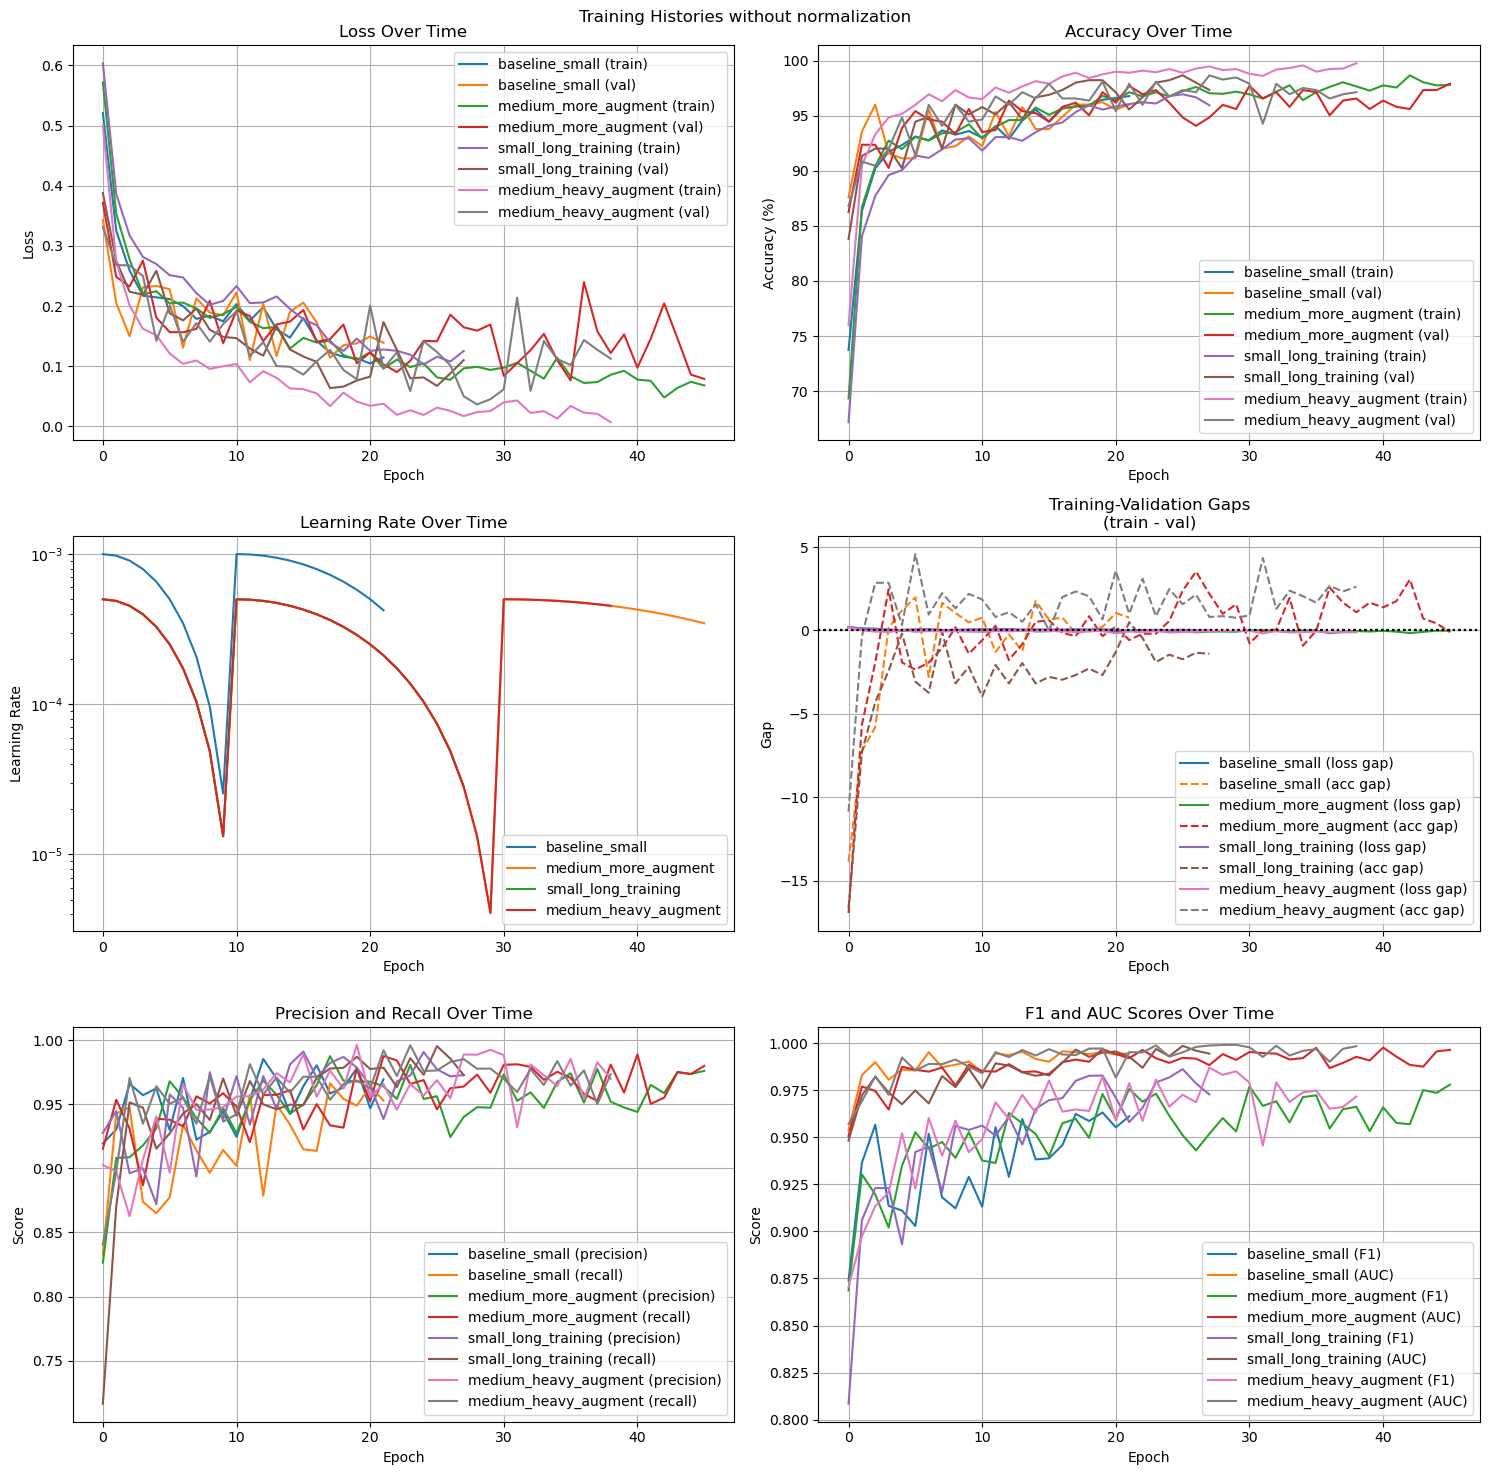

In [5]:
def load_experiment_histories(experiment_dir):
    # Load the summary file
    with open(os.path.join(experiment_dir, 'final_summary.json'), 'r') as f:
        summary = json.load(f)
    
    histories = {}
    for result in summary['results']:
        if result['status'] == 'success' and 'history_path' in result:
            with open(result['history_path'], 'r') as f:
                histories[result['experiment_name']] = json.load(f)
    
    return histories, summary

def plot_experiment_histories(histories):
    """
    Plot training histories including additional metrics if available.
    """
    # Check what additional metrics are available
    additional_metrics = []
    for history in histories.values():
        additional_metrics.extend([k for k in history.keys() 
                                if k.startswith(('val_precision', 'val_recall', 'val_f1', 'val_auc'))])
    additional_metrics = list(set(additional_metrics))
    
    # Create figure with correct number of subplots
    n_rows = 3 if additional_metrics else 2  # Add one more row for additional metrics
    fig, axes = plt.subplots(n_rows, 2, figsize=(15, 5*n_rows))
    
    # Plot basic metrics
    for exp_name, history in histories.items():
        # Loss plot
        axes[0,0].plot(history['train_losses'], label=f'{exp_name} (train)')
        axes[0,0].plot(history['val_losses'], label=f'{exp_name} (val)')
        axes[0,0].set_title('Loss Over Time')
        axes[0,0].set_xlabel('Epoch')
        axes[0,0].set_ylabel('Loss')
        axes[0,0].legend()
        axes[0,0].grid(True)
        
        # Accuracy plot
        axes[0,1].plot(history['train_accuracies'], label=f'{exp_name} (train)')
        axes[0,1].plot(history['val_accuracies'], label=f'{exp_name} (val)')
        axes[0,1].set_title('Accuracy Over Time')
        axes[0,1].set_xlabel('Epoch')
        axes[0,1].set_ylabel('Accuracy (%)')
        axes[0,1].legend()
        axes[0,1].grid(True)
        
        # Learning rate plot
        axes[1,0].plot(history['learning_rates'], label=exp_name)
        axes[1,0].set_title('Learning Rate Over Time')
        axes[1,0].set_xlabel('Epoch')
        axes[1,0].set_ylabel('Learning Rate')
        axes[1,0].set_yscale('log')
        axes[1,0].legend()
        axes[1,0].grid(True)
        
        # Training-validation gaps
        loss_gap = np.array(history['train_losses']) - np.array(history['val_losses'])
        acc_gap = np.array(history['train_accuracies']) - np.array(history['val_accuracies'])
        axes[1,1].plot(loss_gap, label=f'{exp_name} (loss gap)')
        axes[1,1].plot(acc_gap, label=f'{exp_name} (acc gap)', linestyle='--')
        axes[1,1].set_title('Training-Validation Gaps\n(train - val)')
        axes[1,1].set_xlabel('Epoch')
        axes[1,1].set_ylabel('Gap')
        axes[1,1].legend()
        axes[1,1].grid(True)
        axes[1,1].axhline(y=0, color='k', linestyle=':')
        
        # Additional metrics plot
        if additional_metrics:
            # Precision/Recall plot
            axes[2,0].plot(history['val_precisions'], label=f'{exp_name} (precision)')
            axes[2,0].plot(history['val_recalls'], label=f'{exp_name} (recall)')
            axes[2,0].set_title('Precision and Recall Over Time')
            axes[2,0].set_xlabel('Epoch')
            axes[2,0].set_ylabel('Score')
            axes[2,0].legend()
            axes[2,0].grid(True)
            
            # F1 and AUC plot
            axes[2,1].plot(history['val_f1_scores'], label=f'{exp_name} (F1)')
            axes[2,1].plot(history['val_auc_scores'], label=f'{exp_name} (AUC)')
            axes[2,1].set_title('F1 and AUC Scores Over Time')
            axes[2,1].set_xlabel('Epoch')
            axes[2,1].set_ylabel('Score')
            axes[2,1].legend()
            axes[2,1].grid(True)
    
    plt.suptitle('Training Histories without normalization')
    plt.tight_layout()
    plt.show()

# Example usage:
experiment_dir = 'experiments/experiment_20250313_122100'

# experiment_dir = 'experiments/experiment_20250313_105140'
histories, summary = load_experiment_histories(experiment_dir)

# Plot and save
plot_experiment_histories(
    histories
)

Using device: cpu
Loading dataset...
Loading and preprocessing dataset...


Processing boundaries:   0%|          | 0/122 [00:00<?, ?it/s]

Processing unlabeled: 100%|██████████| 347/347 [00:00<00:00, 656.07it/s]


Label distribution: {0: 1032, 1: 1220}

Processing training_output_20250313_122100
Measuring inference speed...



Processing training_output_20250313_122426
Measuring inference speed...



Processing training_output_20250313_123336
Measuring inference speed...



Processing training_output_20250313_123751
Measuring inference speed...



Speed vs Performance Benchmark Results:
--------------------------------------------------------------------------------
Model                          Best AUC   Time (s)   Imgs/sec  
--------------------------------------------------------------------------------
training_output_20250313_12375 0.9992    2.10    1073.05
training_output_20250313_12333 0.9987    1.90    1183.09
training_output_20250313_12242 0.9978    2.12    1060.34
training_output_20250313_12210 0.9958    1.92    1175.85


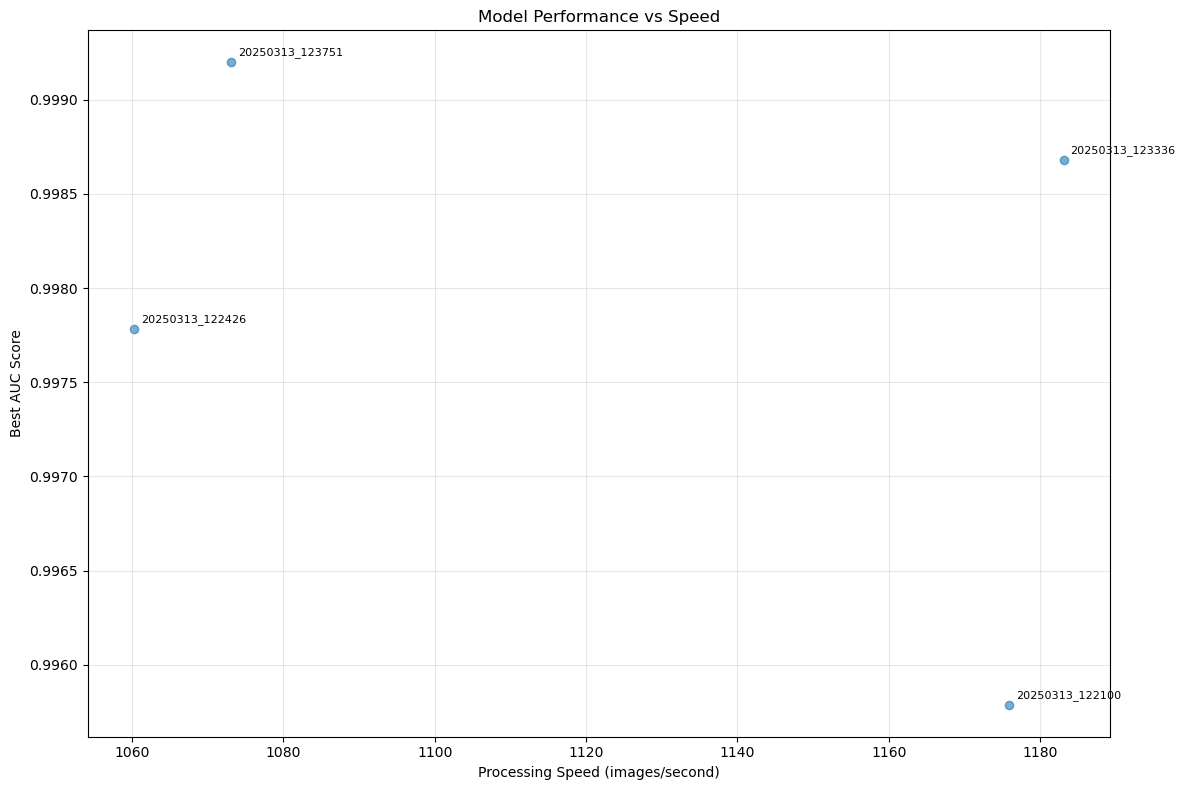

In [6]:
import torch
import time
from tqdm import tqdm
from data_handling import prepare_dataset, BorderDataset
from torch.utils.data import DataLoader
import json
import os
from model import BorderDetector
from collections import defaultdict

def get_model_architecture(checkpoint_path):
    """Determine model architecture from checkpoint"""
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    state_dict = checkpoint['model_state_dict']
    
    # Get conv1 output channels to determine architecture
    conv1_weight = state_dict['conv1.weight']
    conv_channels = [conv1_weight.shape[0]]  # First layer output channels
    
    # Get subsequent conv layers
    for i in range(2, 4):  # conv2 and conv3
        key = f'conv{i}.weight'
        if key in state_dict:
            conv_channels.append(state_dict[key].shape[0])
    
    return conv_channels

def load_model_from_checkpoint(checkpoint_path, device):
    # First determine architecture
    conv_channels = get_model_architecture(checkpoint_path)
    
    # Create model with correct architecture
    model = BorderDetector(conv_channels=conv_channels).to(device)
    
    # Load weights securely
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    return model

def get_best_auc(metrics_path):
    with open(metrics_path, 'r') as f:
        metrics = json.load(f)
    return max(metrics['val_auc_scores']) if 'val_auc_scores' in metrics else None

def measure_inference_speed(model, dataloader, device, num_runs=3):
    model.eval()
    total_times = []
    
    with torch.no_grad():
        for _ in range(num_runs):
            start_time = time.time()
            for images, masks, _ in tqdm(dataloader, desc="Processing batches", leave=False):
                images = images.to(device)
                masks = masks.to(device)
                _ = model(images, masks)
            total_times.append(time.time() - start_time)
    
    avg_time = sum(total_times) / len(total_times)
    images_per_second = len(dataloader.dataset) / avg_time
    return avg_time, images_per_second

def benchmark_models(results_dir, data_dir):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # Load dataset
    print("Loading dataset...")
    images, masks, labels, _ = prepare_dataset(data_dir)
    dataset = BorderDataset(images, masks, labels)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=False)
    
    # Find all model directories
    model_dirs = [d for d in os.listdir(results_dir) 
                 if os.path.isdir(os.path.join(results_dir, d)) 
                 and d.startswith('training_output')]
    
    results = defaultdict(dict)

    # sort models and get last four
    model_dirs = sorted(model_dirs)[-4:]
    
    for model_dir in model_dirs:
        print(f"\nProcessing {model_dir}")
        model_path = os.path.join(results_dir, model_dir)
        
        # Find last checkpoint
        checkpoints = [f for f in os.listdir(model_path) if f.endswith('.pt')]
        if not checkpoints:
            continue
            
        last_checkpoint = max(checkpoints, key=lambda x: int(x.split('_')[-1].split('.')[0]))
        checkpoint_path = os.path.join(model_path, last_checkpoint)
        metrics_path = os.path.join(model_path, 'metrics.json')
        
        try:
            # Get AUC first - if we can't get it, skip this model
            best_auc = get_best_auc(metrics_path)
            if best_auc is None:
                print(f"Skipping {model_dir} - no AUC metrics found")
                continue
                
            # Load model and measure speed
            model = load_model_from_checkpoint(checkpoint_path, device)
            print(f"Measuring inference speed...")
            total_time, imgs_per_sec = measure_inference_speed(model, dataloader, device)
            
            results[model_dir] = {
                'best_auc': best_auc,
                'total_inference_time': total_time,
                'images_per_second': imgs_per_sec
            }
            
        except Exception as e:
            print(f"Error processing {model_dir}: {str(e)}")
    
    return results

# Run benchmark and create visualizations
if __name__ == "__main__":
    results = benchmark_models('results', 'verified_images')

    if not results:
        print("\nNo valid models found to benchmark.")
        exit()

    # Print results table
    print("\nSpeed vs Performance Benchmark Results:")
    print("-" * 80)
    print(f"{'Model':30} {'Best AUC':10} {'Time (s)':10} {'Imgs/sec':10}")
    print("-" * 80)

    for model, metrics in sorted(results.items(), key=lambda x: x[1]['best_auc'], reverse=True):
        print(f"{model[:30]:30} {metrics['best_auc']:.4f}    {metrics['total_inference_time']:.2f}    {metrics['images_per_second']:.2f}")

    # Create visualization
    import matplotlib.pyplot as plt

    aucs = [metrics['best_auc'] for metrics in results.values()]
    speeds = [metrics['images_per_second'] for metrics in results.values()]
    names = [name.replace('training_output_', '') for name in results.keys()]

    plt.figure(figsize=(12, 8))
    plt.scatter(speeds, aucs, alpha=0.6)
    for i, name in enumerate(names):
        plt.annotate(name, (speeds[i], aucs[i]), 
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8)
    plt.xlabel('Processing Speed (images/second)')
    plt.ylabel('Best AUC Score')
    plt.title('Model Performance vs Speed')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

In [13]:
import torch
import onnx
import onnxruntime
import numpy as np
from data_handling import prepare_dataset, BorderDataset
from torch.utils.data import DataLoader
from model import BorderDetector
import os
import matplotlib.pyplot as plt

def get_model_architecture(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    state_dict = checkpoint['model_state_dict']
    conv1_weight = state_dict['conv1.weight']
    conv_channels = [conv1_weight.shape[0]]
    for i in range(2, 4):
        key = f'conv{i}.weight'
        if key in state_dict:
            conv_channels.append(state_dict[key].shape[0])
    return conv_channels

class ONNXWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    
    def forward(self, x):
        # During inference, just pass the RGB image with a dummy mask
        mask = torch.ones_like(x[:, :1, :, :])  # Create a dummy mask of ones
        return self.model(x, mask)

def compare_outputs(pytorch_model, onnx_path, test_dataloader, num_samples=100):
    wrapped_pytorch_model = ONNXWrapper(pytorch_model)
    ort_session = onnxruntime.InferenceSession(onnx_path)
    
    wrapped_pytorch_model.eval()
    differences = []
    pytorch_outputs = []
    
    # Register hooks for activation monitoring
    activations = {}
    def get_activation(name):
        def hook(model, input, output):
            activations[name] = output.detach()
        return hook

    pytorch_model.conv1.register_forward_hook(get_activation('conv1'))
    pytorch_model.conv2.register_forward_hook(get_activation('conv2'))
    pytorch_model.conv3.register_forward_hook(get_activation('conv3'))
    
    print("\nComparing outputs and monitoring activations...")
    with torch.no_grad():
        for i, (images, _, _) in enumerate(test_dataloader):
            if i >= num_samples:
                break
            
            # PyTorch prediction - use only RGB
            pytorch_output = wrapped_pytorch_model(images).numpy()
            pytorch_outputs.append(pytorch_output[0][0])
            
            # ONNX prediction - use only RGB
            ort_inputs = {
                "input": images.numpy()
            }
            onnx_output = ort_session.run(None, ort_inputs)[0]
            
            # Compare outputs
            diff = np.abs(pytorch_output - onnx_output).max()
            differences.append(diff)
            
            if i % 10 == 0:
                print(f"\nBatch {i}:")
                print(f"PyTorch output: {pytorch_output[0][0]:.6f}")
                print(f"ONNX output: {onnx_output[0][0]:.6f}")
                print(f"Max difference: {diff:.6f}")
                
                # Print activation stats
                for name, act in activations.items():
                    print(f"{name}: min={act.min().item():.3f}, max={act.max().item():.3f}, "
                          f"mean={act.mean().item():.3f}, std={act.std().item():.3f}")

    # Print summary statistics
    max_diff = max(differences)
    avg_diff = sum(differences) / len(differences)
    print(f"\nValidation Results:")
    print(f"Maximum difference: {max_diff:.6f}")
    print(f"Average difference: {avg_diff:.6f}")
    
    return max_diff < 1e-5

# Load the best model
model_dir = "results/training_output_20250313_123336"
checkpoints = [f for f in os.listdir(model_dir) if f.endswith('.pt')]
latest_checkpoint = max(checkpoints, key=lambda x: int(x.split('_')[-1].split('.')[0]))
checkpoint_path = os.path.join(model_dir, latest_checkpoint)

# Load dataset
print("Loading dataset...")
images, masks, labels, _ = prepare_dataset('verified_images')
dataset = BorderDataset(images, masks, labels)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

# Get a sample batch for ONNX export
sample_images, _, _ = next(iter(dataloader))

# Create and load model
print("Loading PyTorch model...")
conv_channels = get_model_architecture(checkpoint_path)
model = BorderDetector(conv_channels=conv_channels)
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Export to ONNX
onnx_path = "border_detector.onnx"
print(f"Exporting model to ONNX format: {onnx_path}")
wrapped_model = ONNXWrapper(model)
torch.onnx.export(
    wrapped_model,
    sample_images,
    onnx_path,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "output": {0: "batch_size"}
    },
    opset_version=12,
    do_constant_folding=True
)

# Verify ONNX model
print("Verifying ONNX model...")
onnx_model = onnx.load(onnx_path)
onnx.checker.check_model(onnx_model)

# Compare outputs
is_valid = compare_outputs(model, onnx_path, dataloader)

if is_valid:
    print("\nSuccess! PyTorch model successfully converted to ONNX with matching outputs.")
else:
    print("\nWarning: Significant differences found between PyTorch and ONNX outputs.")

# Print ONNX model info
print("\nONNX Model Info:")
print(f"File size: {os.path.getsize(onnx_path) / (1024*1024):.2f} MB")
print(f"Opset version: {onnx_model.opset_import[0].version}")

# Print input value range
print("Input value range:")
print(f"Images: {sample_images.min().item()} to {sample_images.max().item()}")

Loading dataset...
Loading and preprocessing dataset...


Processing unlabeled: 100%|██████████| 347/347 [00:00<00:00, 743.12it/s]


Label distribution: {0: 1032, 1: 1220}
Loading PyTorch model...
Exporting model to ONNX format: border_detector.onnx
Verifying ONNX model...

Comparing outputs and monitoring activations...

Batch 0:
PyTorch output: 0.997493
ONNX output: 0.997492
Max difference: 0.000000
conv1: min=-1.816, max=1.711, mean=-0.079, std=0.604
conv2: min=-5.740, max=6.710, mean=-0.052, std=0.596
conv3: min=-5.014, max=6.872, mean=0.064, std=0.562

Batch 10:
PyTorch output: 0.004535
ONNX output: 0.004535
Max difference: 0.000000
conv1: min=-1.836, max=1.681, mean=-0.130, std=0.649
conv2: min=-3.312, max=4.214, mean=-0.054, std=0.598
conv3: min=-3.334, max=5.282, mean=0.065, std=0.558

Batch 20:
PyTorch output: 0.004249
ONNX output: 0.004249
Max difference: 0.000000
conv1: min=-1.855, max=1.719, mean=-0.110, std=0.619
conv2: min=-4.910, max=6.119, mean=-0.052, std=0.591
conv3: min=-2.572, max=8.419, mean=0.066, std=0.558

Batch 30:
PyTorch output: 0.004896
ONNX output: 0.004896
Max difference: 0.000001
conv1

In [10]:
import onnx
model = onnx.load("border_detector.onnx")
print(model.graph.input[0].type.tensor_type.shape.dim)  # Should show 3 channels

[dim_param: "batch_size"
, dim_value: 4
, dim_value: 240
, dim_value: 240
]
